# AI-Powered Resume Screening & Candidate Ranking System

NLP + LSTM resume screening, skill matching, candidate ranking, and role-wise Top 10 analysis.


In [1]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# load the dataset
df = pd.read_csv("../dataset/resumes.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6000, 12)


In [3]:
# View Columns
print(df.columns.tolist())

['candidate_id', 'candidate_name', 'resume_text', 'category', 'job_role', 'skills', 'job_description', 'matched_skills', 'missing_skills', 'match_score', 'label', 'recommendation']


In [4]:
# Display sample records
df.head()

,candidate_id,candidate_name,resume_text,category,job_role,skills,job_description,matched_skills,missing_skills,match_score,label,recommendation
0,C00001,Karthik Iyer,Karthik Iyer is a candidate with experience in...,data_analyst,data_analyst,"Python, Machine Learning",Analyze business data using Python SQL Power B...,"Python, Machine Learning","SQL, Power BI, Excel, Statistics, Tableau, Dat...",25.0,0,Not Suitable
1,C00002,Rahul Menon,Rahul Menon is a candidate with experience in ...,data_analyst,data_analyst,"SQL, Machine Learning, Tableau, Statistics","Build data analysis reports, dashboards and in...","SQL, Machine Learning, Tableau, Statistics","Python, Power BI, Excel, Data Analysis",50.0,1,Moderately Suitable
2,C00003,Arjun Verma,Arjun Verma is a candidate with experience in ...,data_analyst,data_analyst,"SQL, Data Analysis, Tableau, Statistics, Pytho...","Build data analysis reports, dashboards and in...","SQL, Data Analysis, Tableau, Statistics, Pytho...","Excel, Machine Learning",75.0,2,Highly Suitable
3,C00004,Aarav Patel,Aarav Patel is a candidate with experience in ...,data_analyst,data_analyst,Statistics,"Build data analysis reports, dashboards and in...",Statistics,"Python, SQL, Power BI, Excel, Machine Learning...",12.5,0,Not Suitable
4,C00005,Rahul Singh,Rahul Singh is a candidate with experience in ...,data_analyst,data_analyst,"Power BI, SQL, Data Analysis, Python",Analyze business data using Python SQL Power B...,"Power BI, SQL, Data Analysis, Python","Excel, Statistics, Machine Learning, Tableau",50.0,1,Moderately Suitable


In [5]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   candidate_id     6000 non-null   str    
 1   candidate_name   6000 non-null   str    
 2   resume_text      6000 non-null   str    
 3   category         6000 non-null   str    
 4   job_role         6000 non-null   str    
 5   skills           6000 non-null   str    
 6   job_description  6000 non-null   str    
 7   matched_skills   6000 non-null   str    
 8   missing_skills   5602 non-null   str    
 9   match_score      6000 non-null   float64
 10  label            6000 non-null   int64  
 11  recommendation   6000 non-null   str    
dtypes: float64(1), int64(1), str(10)
memory usage: 562.6 KB


In [6]:
# Check missing values
print(df.isnull().sum())

candidate_id         0
candidate_name       0
resume_text          0
category             0
job_role             0
skills               0
job_description      0
matched_skills       0
missing_skills     398
match_score          0
label                0
recommendation       0
dtype: int64


In [7]:
# Check duplicate records
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [8]:
# Check target distribution
print(df["label"].value_counts().sort_index())

label
0    2128
1    1854
2    2018
Name: count, dtype: int64


In [9]:
# Check job role distribution
print(df["job_role"].value_counts())

job_role
data_analyst                 1500
machine_learning_engineer    1500
full_stack_developer         1500
business_analyst             1500
Name: count, dtype: int64


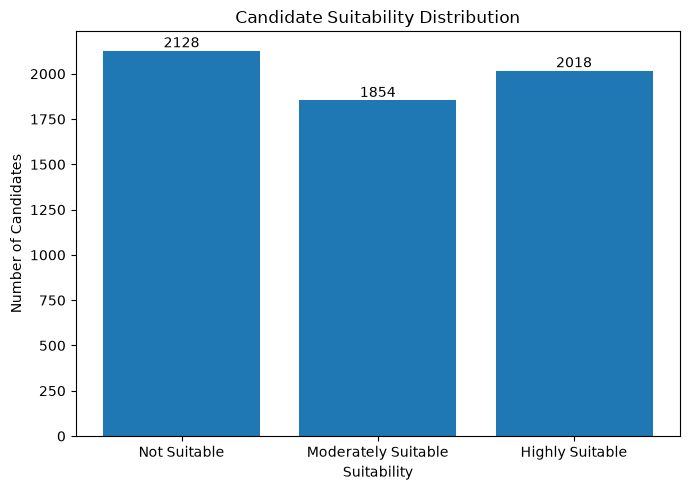

In [10]:
# Visualize labels
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Not Suitable", "Moderately Suitable", "Highly Suitable"],
    label_counts.values
)

plt.xlabel("Suitability")
plt.ylabel("Number of Candidates")
plt.title("Candidate Suitability Distribution")

# Add count on top of each bar
for bar in bars:
    count = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        str(int(count)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [11]:
# Import text preprocessing libraries
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Stop words loaded:", len(stop_words))


Stop words loaded: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# create the cleaning function
def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove unwanted symbols
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Split into words
    words = text.split()

    # Remove stop words
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join words again
    text = " ".join(words)

    return text

In [13]:
# Test the function
sample_text = df["resume_text"].iloc[0]

print("ORIGINAL TEXT:\n")
print(sample_text)

print("\n" + "=" * 80)

print("\nCLEANED TEXT:\n")
print(clean_text(sample_text))

ORIGINAL TEXT:

Karthik Iyer is a candidate with experience in Data Analyst. Skills include Python, Machine Learning. Experienced in developing projects, solving business problems, working with teams and applying technology in real-world projects.


CLEANED TEXT:

karthik iyer candidate experience data analyst skills include python machine learning experienced developing projects solving business problems working teams applying technology real world projects


In [14]:
# Applying preprocessing
df["clean_resume_text"] = df["resume_text"].apply(clean_text)

print("Text preprocessing completed!")

Text preprocessing completed!


In [15]:
# Compare original and cleaned text
comparison = df[
    ["resume_text", "clean_resume_text"]
].head(3)

comparison

,resume_text,clean_resume_text
0,Karthik Iyer is a candidate with experience in...,karthik iyer candidate experience data analyst...
1,Rahul Menon is a candidate with experience in ...,rahul menon candidate experience data analyst ...
2,Arjun Verma is a candidate with experience in ...,arjun verma candidate experience data analyst ...


In [16]:
# Check text length
df["text_length"] = df["clean_resume_text"].apply(
    lambda x: len(x.split())
)

print(df["text_length"].describe())

count    6000.000000
mean       27.666333
std         3.491041
min        22.000000
25%        24.000000
50%        28.000000
75%        31.000000
max        34.000000
Name: text_length, dtype: float64


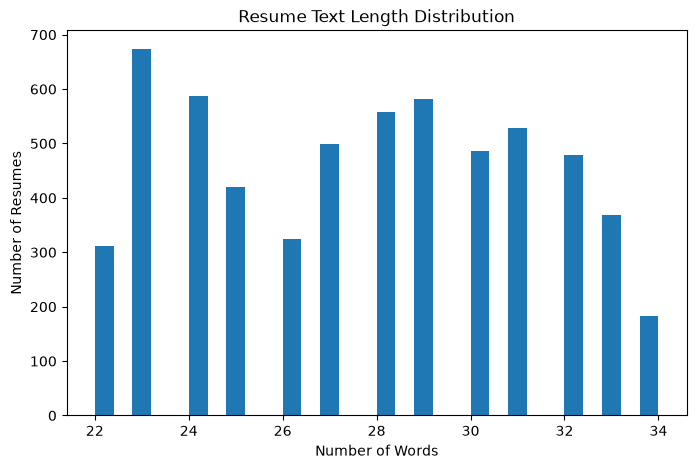

In [17]:
# visualize resume length
plt.figure(figsize=(8, 5))

plt.hist(
    df["text_length"],
    bins=30
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Resumes")
plt.title("Resume Text Length Distribution")

plt.show()

In [18]:
print("Maximum text length :", df["text_length"].max())
print("75% text length     :", df["text_length"].quantile(0.75))
print("50% text length     :", df["text_length"].quantile(0.50))

Maximum text length : 34
75% text length     : 31.0
50% text length     : 28.0


In [19]:
# Train-Test Split (keep original indices)
from sklearn.model_selection import train_test_split

X_text = df["clean_resume_text"]
y = df["label"].values
indices = df.index

X_train_text, X_test_text, y_train, y_test, train_indices, test_indices = train_test_split(
    X_text, y, indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train_text.shape)
print("X_test :", X_test_text.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (4800,)
X_test : (1200,)
y_train: (4800,)
y_test : (1200,)


In [20]:
# Create Tokenizer Using Training Text Only
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

print("Total words in vocabulary:", len(tokenizer.word_index))

Total words in vocabulary: 86


In [21]:
# Save tokenizer
import pickle
with open(
    "../models/tokenizer.pkl",
    "wb"
) as file:

    pickle.dump(
        tokenizer,
        file
    )

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [22]:
maxlen = 34

print("Maximum sequence length:", maxlen)

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Maximum sequence length: 34
Vocabulary Size: 87


In [23]:
# Convert Text to Numerical Sequences and Pad
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

X_train = pad_sequences(X_train_sequences, maxlen=maxlen, padding="post", truncating="post")
X_test = pad_sequences(X_test_sequences, maxlen=maxlen, padding="post", truncating="post")

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Training class distribution:", np.bincount(y_train))
print("Testing class distribution :", np.bincount(y_test))


X_train shape: (4800, 34)
X_test shape : (1200, 34)
Training class distribution: [1703 1483 1614]
Testing class distribution : [425 371 404]


In [24]:
# Define the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(maxlen,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

In [25]:
# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 34, 64)              │           5,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,771 (159.26 KB)

 Trainable params: 40,771 (159.26 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully.")

Model compiled successfully.


In [27]:
# Train the LSTM
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8375 - loss: 0.3732 - val_accuracy: 0.9438 - val_loss: 0.1200
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9870 - loss: 0.0422 - val_accuracy: 0.9396 - val_loss: 0.1351
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9862 - loss: 0.0384 - val_accuracy: 0.9990 - val_loss: 0.0079
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9982 - loss: 0.0097 - val_accuracy: 0.9979 - val_loss: 0.0080
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9898 - loss: 0.0364 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9906 - loss: 0.0231 - val_accuracy: 0.9969 - val_loss: 0.0110
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9937 - loss: 0.0166 - val_accuracy: 0.9990 - val_loss: 0.0028
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9911 - loss: 0.0254 - val_accu

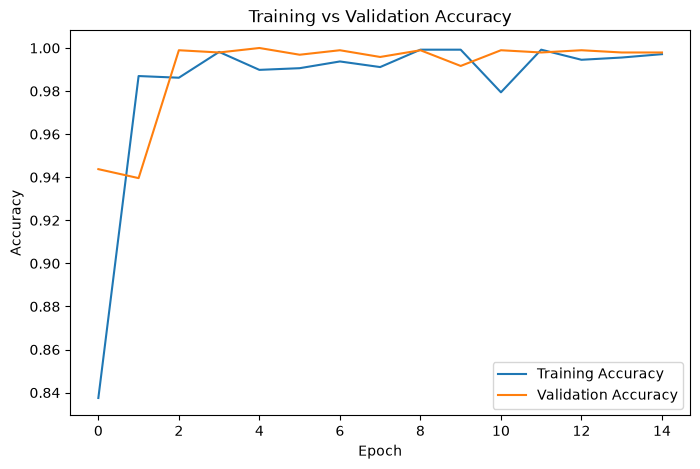

In [28]:
# Training Accuracy vs Validation Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

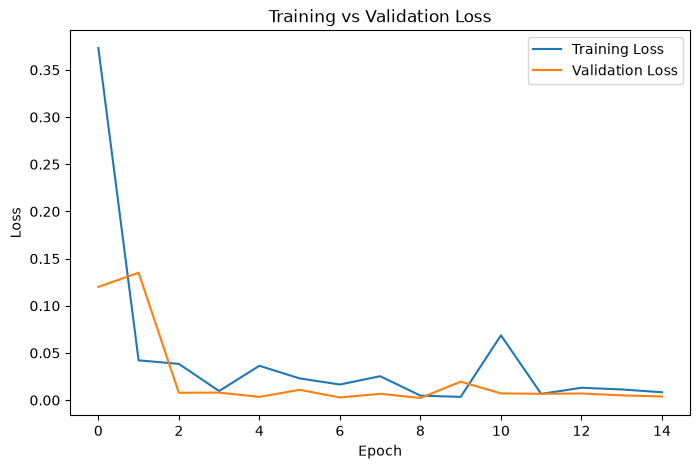

In [29]:
# Training Loss Vs Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [30]:
# Evaluate the model
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 0.0047
Test Loss: 0.004660315811634064
Test Accuracy: 1.0


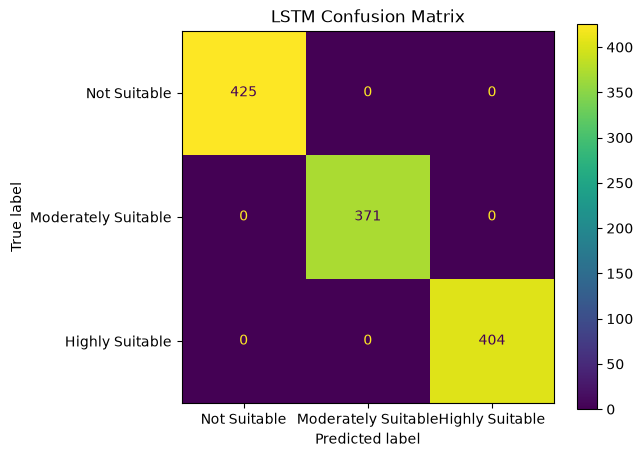

In [31]:
# 29. Generate Predictions and Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_predictions = model.predict(X_test, verbose=0)
predicted_labels = np.argmax(test_predictions, axis=1)
prediction_confidence = np.max(test_predictions, axis=1) * 100

cm = confusion_matrix(y_test, predicted_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Suitable", "Moderately Suitable", "Highly Suitable"]
)
disp.plot()
plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.show()


In [32]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted_labels,
    target_names=["Not Suitable", "Moderately Suitable", "Highly Suitable"]
))


                     precision    recall  f1-score   support

       Not Suitable       1.00      1.00      1.00       425
Moderately Suitable       1.00      1.00      1.00       371
    Highly Suitable       1.00      1.00      1.00       404

           accuracy                           1.00      1200
          macro avg       1.00      1.00      1.00      1200
       weighted avg       1.00      1.00      1.00      1200



In [33]:
# Save Model and Tokenizer
import pickle

model.save("../models/resume_match_model.keras")

with open("../models/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("LSTM model and tokenizer saved successfully.")


LSTM model and tokenizer saved successfully.


In [34]:
# Create Resume Prediction Function
def predict_resume(resume_text):
    cleaned_text = clean_text(resume_text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=maxlen, padding="post", truncating="post")

    probabilities = model.predict(padded_sequence, verbose=0)[0]
    predicted_class = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_class] * 100)

    class_names = {0: "Not Suitable", 1: "Moderately Suitable", 2: "Highly Suitable"}
    print("Predicted Class :", class_names[predicted_class])
    print("Confidence      :", round(confidence, 2), "%")

    return predicted_class, confidence

new_resume = """Experienced Data Analyst with strong skills in Python, SQL, Pandas, NumPy, Excel, Power BI, data visualization, statistics and machine learning. Experienced in analyzing large datasets, creating dashboards and generating business insights."""
predict_resume(new_resume)


Predicted Class : Moderately Suitable
Confidence      : 100.0 %


(1, 99.99593353271484)

In [35]:
# Skill Matching and Candidate Ranking
def count_matched_skills(skills):
    if pd.isna(skills):
        return 0
    return len([skill.strip() for skill in str(skills).split(",") if skill.strip()])

df["matched_skill_count"] = df["matched_skills"].apply(count_matched_skills)

def rank_candidates(job_role, top_n=10):
    candidates = df[df["job_role"] == job_role].copy()
    candidates["missing_skills"] = candidates["missing_skills"].fillna("None")
    candidates = candidates.sort_values(by="match_score", ascending=False)
    return candidates[["candidate_id", "candidate_name", "job_role", "skills", "matched_skills", "missing_skills", "match_score", "matched_skill_count", "label", "recommendation"]].head(top_n)

rank_candidates("data_analyst", top_n=10)


,candidate_id,candidate_name,job_role,skills,matched_skills,missing_skills,match_score,matched_skill_count,label,recommendation
512,C00513,Ananya Sharma,data_analyst,"Machine Learning, Statistics, Tableau, Data An...","Machine Learning, Statistics, Tableau, Data An...",None,100.0,8,2,Highly Suitable
995,C00996,Sneha Gupta,data_analyst,"SQL, Python, Statistics, Machine Learning, Tab...","SQL, Python, Statistics, Machine Learning, Tab...",None,100.0,8,2,Highly Suitable
998,C00999,Rahul Reddy,data_analyst,"Data Analysis, Excel, Python, SQL, Tableau, St...","Data Analysis, Excel, Python, SQL, Tableau, St...",None,100.0,8,2,Highly Suitable
1235,C01236,Aditya Rao,data_analyst,"Statistics, Python, Excel, Machine Learning, D...","Statistics, Python, Excel, Machine Learning, D...",None,100.0,8,2,Highly Suitable
1499,C01500,Nisha Das,data_analyst,"Machine Learning, Statistics, Tableau, Data An...","Machine Learning, Statistics, Tableau, Data An...",None,100.0,8,2,Highly Suitable
1229,C01230,Rahul Rao,data_analyst,"Power BI, Excel, Data Analysis, Python, Statis...","Power BI, Excel, Data Analysis, Python, Statis...",None,100.0,8,2,Highly Suitable
983,C00984,Pooja Rao,data_analyst,"Data Analysis, Machine Learning, Statistics, T...","Data Analysis, Machine Learning, Statistics, T...",None,100.0,8,2,Highly Suitable
719,C00720,Meera Menon,data_analyst,"Statistics, Power BI, Python, Machine Learning...","Statistics, Power BI, Python, Machine Learning...",None,100.0,8,2,Highly Suitable
1304,C01305,Manoj Singh,data_analyst,"SQL, Power BI, Excel, Statistics, Python, Tabl...","SQL, Power BI, Excel, Statistics, Python, Tabl...",None,100.0,8,2,Highly Suitable
359,C00360,Shreya Reddy,data_analyst,"Tableau, SQL, Statistics, Data Analysis, Machi...","Tableau, SQL, Statistics, Data Analysis, Machi...",None,100.0,8,2,Highly Suitable


In [36]:
# LSTM Results and Final Ranking Dataset
label_names = {0: "Not Suitable", 1: "Moderately Suitable", 2: "Highly Suitable"}

lstm_results = pd.DataFrame({
    "candidate_id": df.loc[test_indices, "candidate_id"].values,
    "predicted_label": predicted_labels,
    "lstm_confidence": prediction_confidence
})
lstm_results["lstm_prediction"] = lstm_results["predicted_label"].map(label_names)

test_candidates = df.loc[test_indices].copy()
test_candidates = test_candidates.merge(
    lstm_results[["candidate_id", "lstm_prediction", "lstm_confidence"]],
    on="candidate_id", how="left"
)

final_ranking = test_candidates[["candidate_id", "candidate_name", "job_role", "skills", "matched_skills", "missing_skills", "match_score", "lstm_prediction", "lstm_confidence", "recommendation"]].copy()
final_ranking["missing_skills"] = final_ranking["missing_skills"].fillna("None")
final_ranking = final_ranking.sort_values(by="match_score", ascending=False).reset_index(drop=True)
final_ranking["rank"] = np.arange(1, len(final_ranking) + 1)

final_ranking.head(10)


,candidate_id,candidate_name,job_role,skills,matched_skills,missing_skills,match_score,lstm_prediction,lstm_confidence,recommendation,rank
0,C01209,Manoj Gupta,data_analyst,"Power BI, Statistics, SQL, Python, Data Analys...","Power BI, Statistics, SQL, Python, Data Analys...",None,100.0,Highly Suitable,99.999931,Highly Suitable,1
1,C03639,Arjun Patel,full_stack_developer,"CSS, JavaScript, MongoDB, REST API, SQL, HTML,...","CSS, JavaScript, MongoDB, REST API, SQL, HTML,...",None,100.0,Highly Suitable,99.999329,Highly Suitable,2
2,C05661,Meera Iyer,business_analyst,"Business Analysis, Requirements Gathering, Pow...","Business Analysis, Requirements Gathering, Pow...",None,100.0,Highly Suitable,99.999855,Highly Suitable,3
3,C01203,Aarav Iyer,data_analyst,"Python, Data Analysis, Tableau, Statistics, Po...","Python, Data Analysis, Tableau, Statistics, Po...",None,100.0,Highly Suitable,99.999931,Highly Suitable,4
4,C03705,Priya Reddy,full_stack_developer,"MongoDB, React, Express, CSS, HTML, SQL, Git, ...","MongoDB, React, Express, CSS, HTML, SQL, Git, ...",None,100.0,Highly Suitable,99.999413,Highly Suitable,5
5,C03528,Manoj Reddy,full_stack_developer,"JavaScript, HTML, CSS, Git, Express, SQL, Reac...","JavaScript, HTML, CSS, Git, Express, SQL, Reac...",None,100.0,Highly Suitable,99.999413,Highly Suitable,6
6,C02004,Rohan Kumar,machine_learning_engineer,"Keras, TensorFlow, Deep Learning, Python, NumP...","Keras, TensorFlow, Deep Learning, Python, NumP...",None,100.0,Highly Suitable,99.997963,Highly Suitable,7
7,C00924,Aditya Verma,data_analyst,"SQL, Power BI, Statistics, Tableau, Python, Da...","SQL, Power BI, Statistics, Tableau, Python, Da...",None,100.0,Highly Suitable,99.999939,Highly Suitable,8
8,C05508,Ananya Kumar,business_analyst,"Requirements Gathering, Data Analysis, Excel, ...","Requirements Gathering, Data Analysis, Excel, ...",None,100.0,Highly Suitable,99.999893,Highly Suitable,9
9,C00834,Aarav Gupta,data_analyst,"Python, Excel, Tableau, SQL, Machine Learning,...","Python, Excel, Tableau, SQL, Machine Learning,...",None,100.0,Highly Suitable,99.999939,Highly Suitable,10


In [37]:
# Top 10 Candidates for Each Job Role
roles = ["data_analyst", "machine_learning_engineer", "full_stack_developer", "business_analyst"]

top_candidates_by_role = {}
for role in roles:
    top_candidates_by_role[role] = (
        final_ranking[final_ranking["job_role"] == role]
        .sort_values(by="match_score", ascending=False)
        .head(10).copy()
    )

for role in roles:
    print("\n" + "=" * 80)
    print("TOP 10:", role.upper())
    print("=" * 80)
    display(top_candidates_by_role[role][["rank", "candidate_id", "candidate_name", "match_score", "lstm_prediction", "lstm_confidence", "missing_skills", "recommendation"]])



TOP 10: DATA_ANALYST


,rank,candidate_id,candidate_name,match_score,lstm_prediction,lstm_confidence,missing_skills,recommendation
0,1,C01209,Manoj Gupta,100.0,Highly Suitable,99.999931,None,Highly Suitable
3,4,C01203,Aarav Iyer,100.0,Highly Suitable,99.999931,None,Highly Suitable
7,8,C00924,Aditya Verma,100.0,Highly Suitable,99.999939,None,Highly Suitable
9,10,C00834,Aarav Gupta,100.0,Highly Suitable,99.999939,None,Highly Suitable
11,12,C01413,Manoj Patel,100.0,Highly Suitable,99.999931,None,Highly Suitable
12,13,C00486,Pooja Nair,100.0,Highly Suitable,99.999931,None,Highly Suitable
16,17,C01488,Aditya Menon,100.0,Highly Suitable,99.999931,None,Highly Suitable
20,21,C01254,Vivek Rao,100.0,Highly Suitable,99.999931,None,Highly Suitable
32,33,C00354,Sneha Sharma,100.0,Highly Suitable,99.999931,None,Highly Suitable
35,36,C01473,Aditya Das,100.0,Highly Suitable,99.999939,None,Highly Suitable



TOP 10: MACHINE_LEARNING_ENGINEER


,rank,candidate_id,candidate_name,match_score,lstm_prediction,lstm_confidence,missing_skills,recommendation
6,7,C02004,Rohan Kumar,100.0,Highly Suitable,99.997963,None,Highly Suitable
10,11,C02694,Divya Iyer,100.0,Highly Suitable,99.994087,None,Highly Suitable
13,14,C01677,Kavya Reddy,100.0,Highly Suitable,99.998665,None,Highly Suitable
15,16,C02685,Ananya Kumar,100.0,Highly Suitable,99.998390,None,Highly Suitable
17,18,C02574,Aishwarya Patel,100.0,Highly Suitable,99.997604,None,Highly Suitable
19,20,C02211,Arjun Sharma,100.0,Highly Suitable,99.997093,None,Highly Suitable
22,23,C01749,Rahul Gupta,100.0,Highly Suitable,99.996826,None,Highly Suitable
33,34,C02985,Aarav Patel,100.0,Highly Suitable,99.997696,None,Highly Suitable
40,41,C02631,Vikram Nair,100.0,Highly Suitable,99.991974,None,Highly Suitable
56,57,C02862,Rohan Verma,100.0,Highly Suitable,99.998581,None,Highly Suitable



TOP 10: FULL_STACK_DEVELOPER


,rank,candidate_id,candidate_name,match_score,lstm_prediction,lstm_confidence,missing_skills,recommendation
1,2,C03639,Arjun Patel,100.0,Highly Suitable,99.999329,None,Highly Suitable
4,5,C03705,Priya Reddy,100.0,Highly Suitable,99.999413,None,Highly Suitable
5,6,C03528,Manoj Reddy,100.0,Highly Suitable,99.999413,None,Highly Suitable
14,15,C04242,Vikram Nair,100.0,Highly Suitable,99.999168,None,Highly Suitable
21,22,C03876,Vikram Rao,100.0,Highly Suitable,99.999413,None,Highly Suitable
23,24,C04491,Vivek Das,100.0,Highly Suitable,99.999382,None,Highly Suitable
24,25,C04182,Divya Gupta,100.0,Highly Suitable,99.999306,None,Highly Suitable
26,27,C03891,Aditya Kumar,100.0,Highly Suitable,99.999107,None,Highly Suitable
30,31,C04176,Meera Rao,100.0,Highly Suitable,99.999443,None,Highly Suitable
31,32,C04038,Priya Iyer,100.0,Highly Suitable,99.999222,None,Highly Suitable



TOP 10: BUSINESS_ANALYST


,rank,candidate_id,candidate_name,match_score,lstm_prediction,lstm_confidence,missing_skills,recommendation
2,3,C05661,Meera Iyer,100.0,Highly Suitable,99.999855,None,Highly Suitable
8,9,C05508,Ananya Kumar,100.0,Highly Suitable,99.999893,None,Highly Suitable
18,19,C04812,Shreya Das,100.0,Highly Suitable,99.999908,None,Highly Suitable
25,26,C05526,Meera Das,100.0,Highly Suitable,99.999916,None,Highly Suitable
27,28,C05961,Manoj Gupta,100.0,Highly Suitable,99.999908,None,Highly Suitable
28,29,C05307,Sanjay Kumar,100.0,Highly Suitable,99.999908,None,Highly Suitable
29,30,C05403,Arjun Rao,100.0,Highly Suitable,99.999870,None,Highly Suitable
34,35,C05319,Kavya Reddy,100.0,Highly Suitable,99.999870,None,Highly Suitable
36,37,C04905,Rahul Gupta,100.0,Highly Suitable,99.999908,None,Highly Suitable
37,38,C05424,Aarav Menon,100.0,Highly Suitable,99.999908,None,Highly Suitable


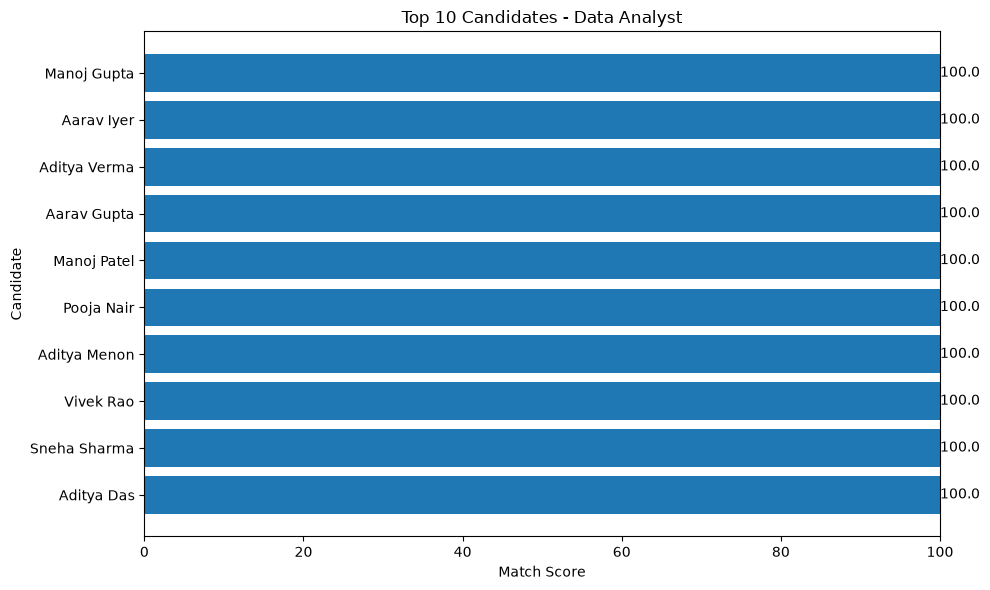

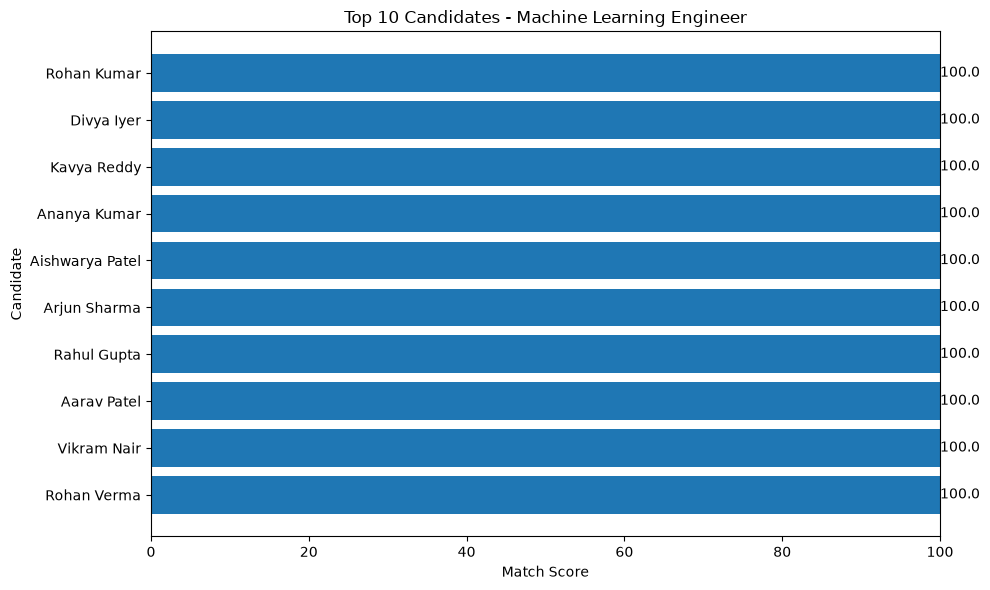

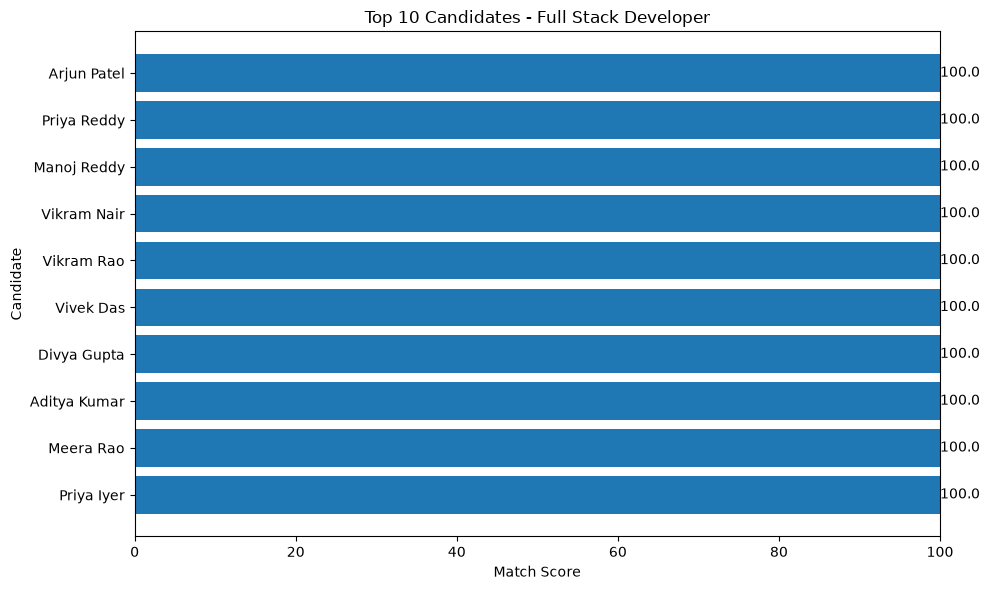

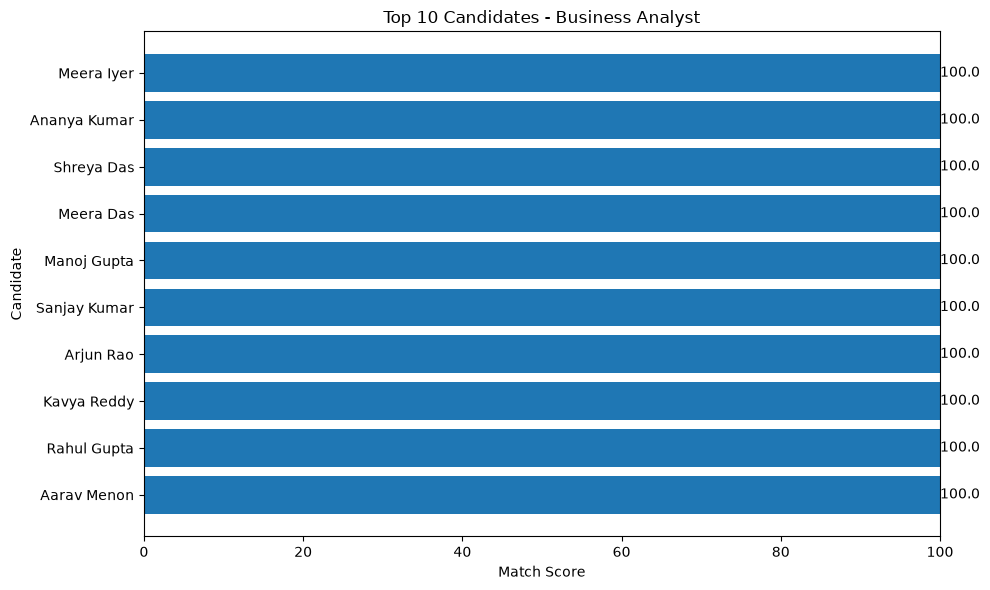

In [38]:
# Top 10 Match-Score Visualization by Role
for role in roles:
    top_10 = top_candidates_by_role[role]
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_10["candidate_name"], top_10["match_score"])
    plt.xlabel("Match Score")
    plt.ylabel("Candidate")
    plt.title(f"Top 10 Candidates - {role.replace('_', ' ').title()}")
    plt.xlim(0, 100)
    plt.gca().invert_yaxis()
    for bar in bars:
        plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"{bar.get_width():.1f}", va="center", ha="left")
    plt.tight_layout()
    plt.show()


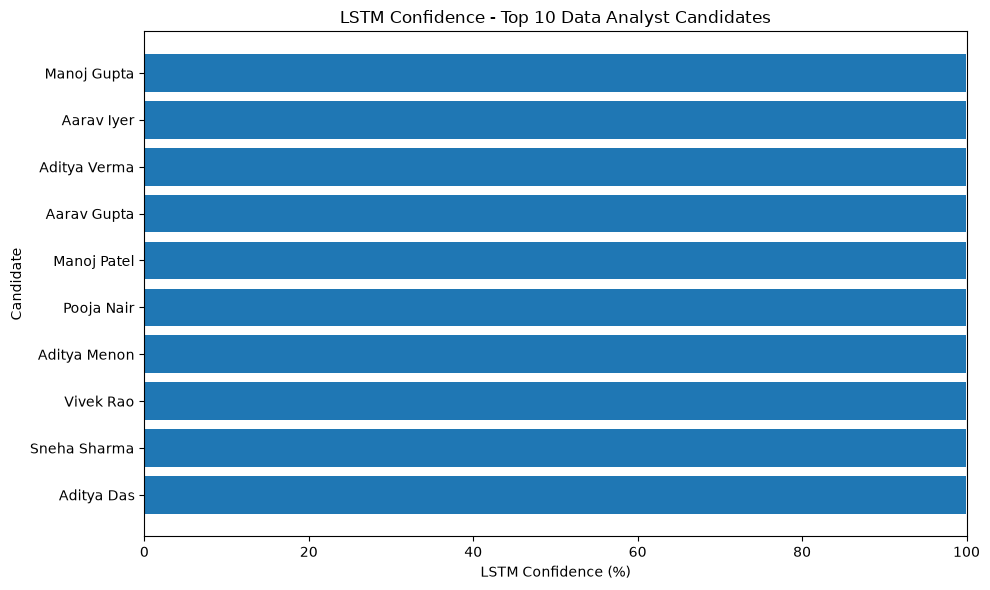

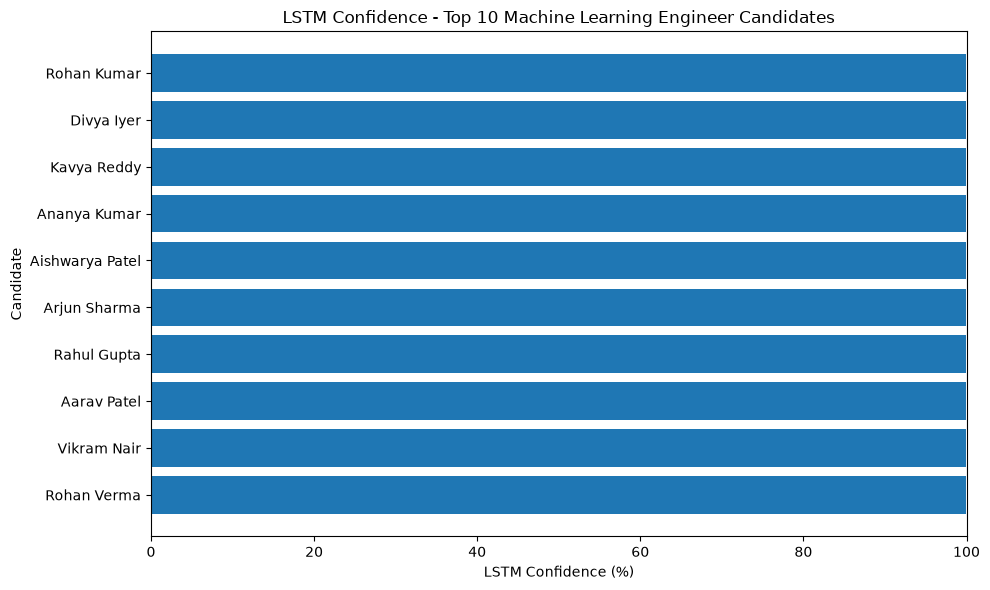

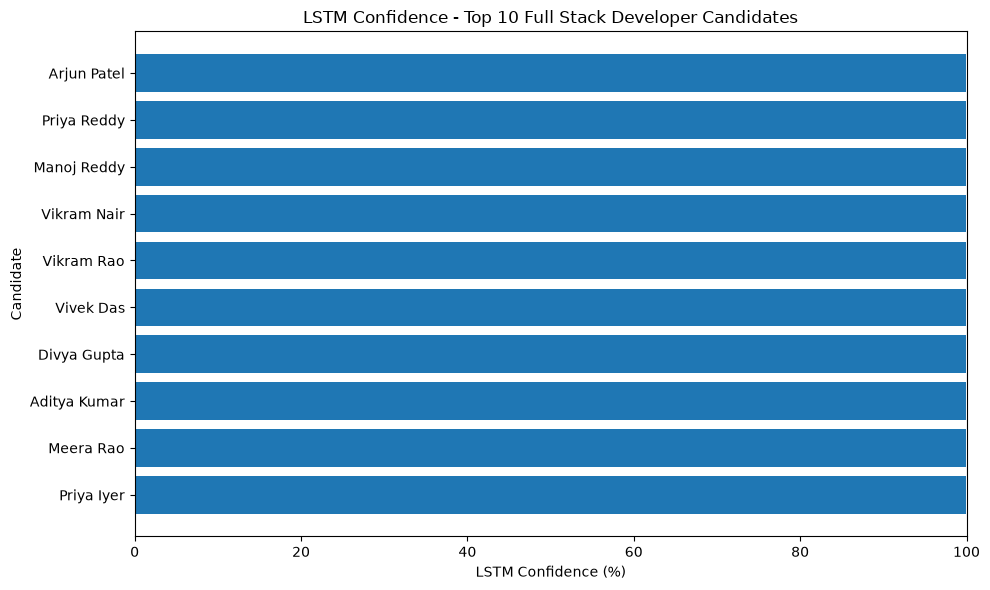

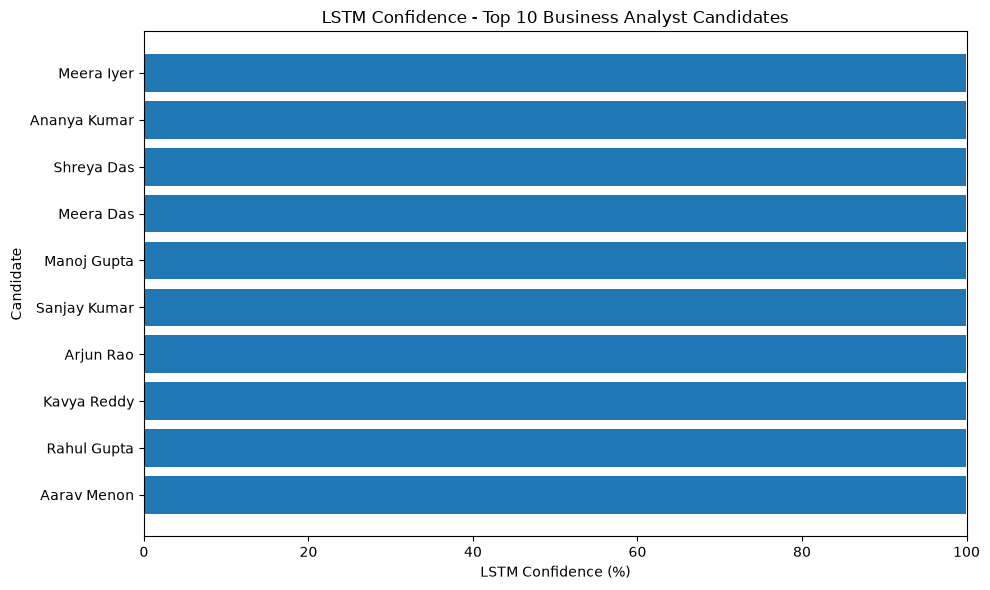

In [39]:
# LSTM Confidence Visualization by Role
for role in roles:
    top_10 = top_candidates_by_role[role]
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_10["candidate_name"], top_10["lstm_confidence"])
    plt.xlabel("LSTM Confidence (%)")
    plt.ylabel("Candidate")
    plt.title(f"LSTM Confidence - Top 10 {role.replace('_', ' ').title()} Candidates")
    plt.xlim(0, 100)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


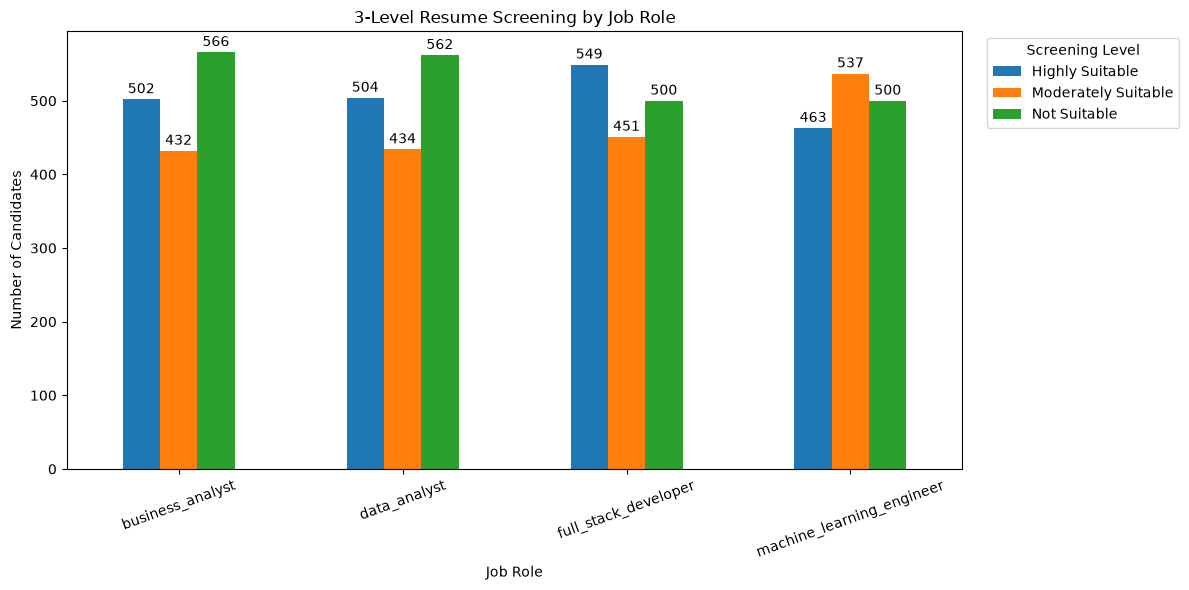

In [84]:
# 3-Level Suitability Visualization by Role
screening_levels = {0: "Not Suitable", 1: "Moderately Suitable", 2: "Highly Suitable"}
df["screening_level"] = df["label"].map(screening_levels)

role_screening = pd.crosstab(df["job_role"], df["screening_level"])
role_screening = role_screening.reindex(columns=["Highly Suitable", "Moderately Suitable", "Not Suitable"], fill_value=0)

ax = role_screening.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Job Role")
plt.ylabel("Number of Candidates")
plt.title("3-Level Resume Screening by Job Role")
plt.xticks(rotation=20)
plt.legend(title="Screening Level",
           bbox_to_anchor=(1.02, 1),
           loc="upper left")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2)
plt.tight_layout()
plt.show()
